# Loan Default Risk — Modelling and Evaluation

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier


from src.loader import load_and_merge
from src.features import engineer_model_features, engineer_pltr_features

from src.model import (
    get_models, get_param_grids, tune_model, save_model, predict_proba,
    build_pipeline, run_smote_ablation, build_stacking_ensemble, calibrate_model
)
from src.evaluate import (
    evaluate_model, find_optimal_threshold,
    plot_confusion_matrix, plot_roc_curves, plot_shap_summary
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

%matplotlib inline

## 1. Load, Merge, and Engineer Features

In [3]:
train_df = load_and_merge(split="train")
print(f"Merged training data shape: {train_df.shape}")
train_df.head()

Merged training data shape: (4376, 35)


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients,prev_loan_count,prev_avg_loanamount,prev_max_loanamount,prev_avg_totaldue,prev_avg_termdays,prev_max_days_late,prev_late_payment_rate,prev_total_late_payments,prev_avg_interest_ratio,prev_avg_loan_duration,prev_was_referred,recent_1_paid_late,recent_2_late_rate,consecutive_late_streak,consecutive_ontime_streak,ever_recovered,last3_trend
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0000,34500.0000,30,NaN,Good,1972-01-15 00:00:00.000000,Other,3.4320,6.4331,Diamond Bank,NaN,Permanent,Post-Graduate,11.0000,18181.8182,30000.0000,22081.8182,30.0000,39.0000,0.2727,3.0000,0.2291,29.4545,0.0000,0.0000,0.0000,0.0000,3.0000,1.0000,1.0000
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0000,17250.0000,30,NaN,Good,1985-08-23 00:00:00.000000,Savings,3.8853,7.3207,GT Bank,"DUGBE,IBADAN",Permanent,Graduate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0000,22250.0000,15,NaN,Good,1984-09-18 00:00:00.000000,Other,11.1393,10.2920,EcoBank,NaN,Permanent,NaN,6.0000,10000.0000,10000.0000,11750.0000,17.5000,30.0000,0.1667,1.0000,0.1750,18.1667,0.0000,0.0000,0.0000,0.0000,2.0000,1.0000,0.0000
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0000,11500.0000,15,NaN,Good,1977-10-10 00:00:00.000000,Savings,3.9858,7.4917,First Bank,NaN,Permanent,NaN,2.0000,10000.0000,10000.0000,12250.0000,22.5000,11.0000,1.0000,2.0000,0.2250,31.5000,0.0000,1.0000,1.0000,2.0000,0.0000,0.0000,0.0000
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0000,44000.0000,30,NaN,Good,1986-09-07 00:00:00.000000,Other,7.4579,9.0766,GT Bank,NaN,Permanent,Primary,8.0000,18750.0000,30000.0000,23550.0000,37.5000,-1.0000,0.0000,0.0000,0.2587,27.0000,0.0000,0.0000,0.0000,0.0000,8.0000,0.0000,1.0000


In [4]:
X, y = engineer_model_features(train_df, is_train=True)
print(f"Feature matrix shape: {X.shape}")
print(f"Class balance: {y.mean()*100:.1f}% Good, {(1-y.mean())*100:.1f}% Bad")

Feature matrix shape: (4376, 52)
Class balance: 78.2% Good, 21.8% Bad


## 2. Time-Based Train / Validation Split

In [5]:
# Time-based split — train on oldest 80%, validate on most recent 20%
train_df_sorted = train_df.copy()
train_df_sorted["approveddate"] = pd.to_datetime(train_df_sorted["approveddate"])
train_df_sorted = train_df_sorted.sort_values("approveddate").reset_index(drop=True)

split_idx = int(len(train_df_sorted) * 0.8)
train_split = train_df_sorted.iloc[:split_idx]
val_split   = train_df_sorted.iloc[split_idx:]

X_train, y_train = engineer_model_features(train_split, is_train=True)
X_val, y_val     = engineer_model_features(val_split,   is_train=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

print(f"Training set:   {X_train.shape} | {train_split['approveddate'].min().date()} to {train_split['approveddate'].max().date()}")
print(f"Validation set: {X_val.shape}   | {val_split['approveddate'].min().date()} to {val_split['approveddate'].max().date()}")
print(f"Training Bad rate:   {(1-y_train.mean())*100:.1f}%")
print(f"Validation Bad rate: {(1-y_val.mean())*100:.1f}%")

Training set:   (3500, 52) | 2017-07-01 to 2017-07-25
Validation set: (876, 52)   | 2017-07-25 to 2017-07-30
Training Bad rate:   21.6%
Validation Bad rate: 22.4%


In [6]:
X_train_pltr = engineer_pltr_features(X_train, y_train, X_train)
X_val_pltr = engineer_pltr_features(X_train, y_train, X_val)

print(f"Features before PLTR: {X_train.shape[1]}")
print(f"Features after PLTR:  {X_train_pltr.shape[1]}")

# Use PLTR-augmented features for all downstream modelling
X_train = X_train_pltr
X_val = X_val_pltr

Features before PLTR: 52
Features after PLTR:  56


## 3. Baseline Model — Logistic Regression

In [7]:
baseline = build_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    scale=True
)
baseline.fit(X_train, y_train)
baseline_proba = predict_proba(baseline, X_val)
baseline_metrics = evaluate_model(y_val, baseline_proba)
print("Baseline Logistic Regression:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")

Baseline Logistic Regression:
  roc_auc: 0.7180
  f1_macro: 0.5707
  f1_weighted: 0.6343
  precision_bad: 0.3281
  recall_bad: 0.7449
  f1_bad: 0.4555
  precision_good: 0.8840
  recall_good: 0.5603
  f1_good: 0.6859
  accuracy: 0.6016
  threshold: 0.5000


## 4. SMOTE Ablation

In [8]:
print("Running SMOTE ablation...")
ablation_results = run_smote_ablation(X_train, y_train, X_val, y_val)
ablation_results

Running SMOTE ablation...
  Running strategy: none
  Running strategy: class_weight
  Running strategy: smote
  Running strategy: smote_tomek


,model,strategy,roc_auc,f1_bad,recall_bad
0,logistic_regression,none,0.7181,0.4731,0.4490
1,logistic_regression,smote_tomek,0.7212,0.4544,0.6990
2,logistic_regression,class_weight,0.7192,0.4533,0.6684
3,logistic_regression,smote,0.7212,0.4529,0.6990
4,random_forest,smote_tomek,0.7235,0.4802,0.5561
5,random_forest,class_weight,0.7215,0.4680,0.5408
6,random_forest,smote,0.7230,0.4656,0.5357
7,random_forest,none,0.7189,0.3345,0.2398
8,xgboost,class_weight,0.6904,0.3708,0.3112
9,xgboost,smote_tomek,0.6943,0.3400,0.2602


## 5. Model Comparison (Pre-tuning)

In [9]:
models = get_models()
results_pretune = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    proba = predict_proba(pipeline, X_val)
    metrics = evaluate_model(y_val, proba)
    results_pretune[name] = metrics
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | F1-macro={metrics['f1_macro']:.4f}")

summary_pretune = pd.DataFrame(results_pretune).T
summary_pretune[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

logistic_regression: ROC-AUC=0.7180 | F1-macro=0.5707
random_forest: ROC-AUC=0.6714 | F1-macro=0.6167
xgboost: ROC-AUC=0.6621 | F1-macro=0.5982
catboost: ROC-AUC=0.7186 | F1-macro=0.6339


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.7180,0.5707,0.4555,0.7449,0.3281
random_forest,0.6714,0.6167,0.3738,0.3061,0.4800
xgboost,0.6621,0.5982,0.3299,0.2449,0.5053
catboost,0.7186,0.6339,0.4814,0.6276,0.3905


## 6. Hyperparameter Tuning — RandomizedSearchCV

**This cell takes several minutes to run.**

In [10]:
param_grids = get_param_grids()
tuned_models = {}

for name, pipeline in get_models().items():
    search = tune_model(
        name=name,
        pipeline=pipeline,
        param_grid=param_grids[name],
        X_train=X_train,
        y_train=y_train,
        n_iter=30,
        cv=5,
        use_time_cv=False
    )
    tuned_models[name] = search.best_estimator_

Tuning logistic_regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best score: 0.7190
  Best params: {'model__solver': 'liblinear', 'model__C': 0.01}
Tuning random_forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best score: 0.7161
  Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 10}
Tuning xgboost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best score: 0.3053
  Best params: {'model__subsample': 0.7, 'model__scale_pos_weight': 1, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.2, 'model__colsample_bytree': 1.0}
Tuning catboost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best score: 0.5290
  Best params: {'model__subsample': 0.7, 'model__learning_rate': 0.1, 'model__l2_leaf_reg': 10, 'model__iterations': 200, 'model__depth': 5}


In [11]:
results_tuned = {}
roc_data = {}

for name, model in tuned_models.items():
    proba = predict_proba(model, X_val)
    metrics = evaluate_model(y_val, proba)
    results_tuned[name] = metrics
    roc_data[name] = {"y_true": y_val, "y_pred_proba": proba}
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | F1-macro={metrics['f1_macro']:.4f} | Recall-bad={metrics['recall_bad']:.4f}")

summary_tuned = pd.DataFrame(results_tuned).T
summary_tuned[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

logistic_regression: ROC-AUC=0.7246 | F1-macro=0.5843 | Recall-bad=0.6939
random_forest: ROC-AUC=0.7121 | F1-macro=0.6565 | Recall-bad=0.5102
xgboost: ROC-AUC=0.6459 | F1-macro=0.5864 | Recall-bad=0.3214
catboost: ROC-AUC=0.7144 | F1-macro=0.6051 | Recall-bad=0.6429


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.7246,0.5843,0.4533,0.6939,0.3366
random_forest,0.7121,0.6565,0.4773,0.5102,0.4484
xgboost,0.6459,0.5864,0.3452,0.3214,0.3728
catboost,0.7144,0.6051,0.4582,0.6429,0.3559


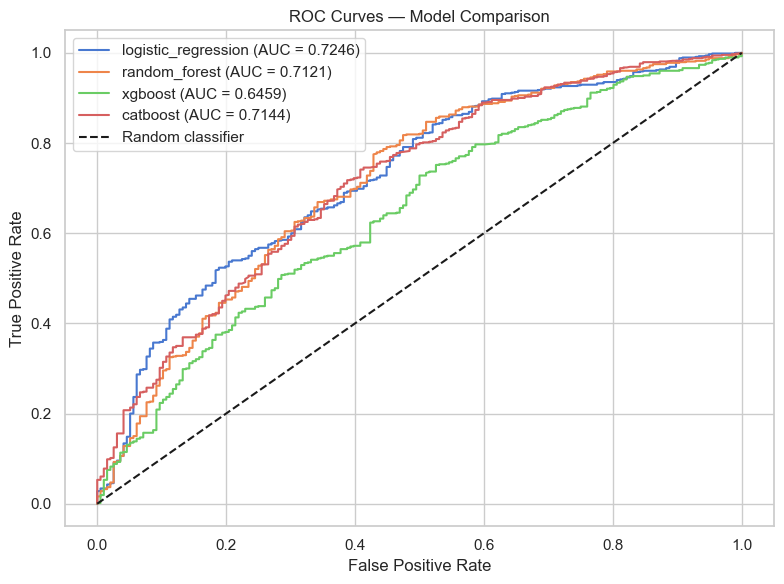

In [12]:
plot_roc_curves(roc_data)

## 7. Threshold Optimisation (Best Individual Model)

In [13]:
best_model_name = max(results_tuned, key=lambda k: results_tuned[k]["roc_auc"])
best_model = tuned_models[best_model_name]
best_proba = predict_proba(best_model, X_val)

print(f"Best model: {best_model_name}")
optimal_threshold = find_optimal_threshold(y_val, best_proba)

metrics_default = evaluate_model(y_val, best_proba, threshold=0.5)
metrics_optimal = evaluate_model(y_val, best_proba, threshold=optimal_threshold)

comparison = pd.DataFrame({
    "threshold=0.5": metrics_default,
    f"threshold={optimal_threshold:.3f}": metrics_optimal
}).T
comparison[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

Best model: logistic_regression
Optimal threshold: 0.5700 (F2.0 Bad class: 0.6379)


,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
threshold=0.5,0.7246,0.5843,0.4533,0.6939,0.3366
threshold=0.570,0.7246,0.5108,0.4505,0.8827,0.3024


## 8. Stacking Ensemble — Configuration Comparison

In [14]:
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)

lr_base  = tuned_models["logistic_regression"]
rf_base  = tuned_models["random_forest"]
xgb_base = tuned_models["xgboost"]
cat_base = tuned_models["catboost"]

print("Calibrating RF...")
rf_cal = calibrate_model(rf_base, X_train_imp, y_train, method="sigmoid")

stack_configs = {
    "LR+RF (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF+XGB (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal), ("xgb", xgb_base)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF+CAT (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal), ("cat", cat_base)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF+XGB+CAT (C=0.1)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal), ("xgb", xgb_base), ("cat", cat_base)],
        final_estimator=LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
    "LR+RF (C=1.0)": StackingClassifier(
        estimators=[("lr", lr_base), ("rf", rf_cal)],
        final_estimator=LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42),
        cv=5, n_jobs=-1
    ),
}

stack_results = {}
for config_name, stack in stack_configs.items():
    print(f"  Fitting: {config_name}")
    stack.fit(X_train_imp, y_train)
    proba = predict_proba(stack, X_val_imp)
    opt_thresh = find_optimal_threshold(y_val, proba)
    metrics = evaluate_model(y_val, proba, threshold=opt_thresh)
    stack_results[config_name] = {
        "roc_auc": metrics["roc_auc"],
        "f1_bad":  metrics["f1_bad"],
        "recall_bad": metrics["recall_bad"],
        "precision_bad": metrics["precision_bad"],
        "threshold": opt_thresh,
        "model": stack
    }
    print(f"    ROC-AUC={metrics['roc_auc']:.4f} | F1 Bad={metrics['f1_bad']:.4f} | Recall Bad={metrics['recall_bad']:.4f}")

stack_summary = pd.DataFrame({k: {m: v for m, v in v.items() if m != "model"}
                               for k, v in stack_results.items()}).T
stack_summary[["roc_auc", "f1_bad", "recall_bad", "precision_bad", "threshold"]]

Calibrating RF...
  Fitting: LR+RF (C=0.1)
Optimal threshold: 0.5800 (F2.0 Bad class: 0.6392)
    ROC-AUC=0.7324 | F1 Bad=0.4481 | Recall Bad=0.8929
  Fitting: LR+RF+XGB (C=0.1)
Optimal threshold: 0.5700 (F2.0 Bad class: 0.6344)
    ROC-AUC=0.7270 | F1 Bad=0.4543 | Recall Bad=0.8622
  Fitting: LR+RF+CAT (C=0.1)
Optimal threshold: 0.5800 (F2.0 Bad class: 0.6384)
    ROC-AUC=0.7316 | F1 Bad=0.4511 | Recall Bad=0.8827
  Fitting: LR+RF+XGB+CAT (C=0.1)
Optimal threshold: 0.5900 (F2.0 Bad class: 0.6337)
    ROC-AUC=0.7276 | F1 Bad=0.4453 | Recall Bad=0.8827
  Fitting: LR+RF (C=1.0)
Optimal threshold: 0.5800 (F2.0 Bad class: 0.6387)
    ROC-AUC=0.7327 | F1 Bad=0.4599 | Recall Bad=0.8622


,roc_auc,f1_bad,recall_bad,precision_bad,threshold
LR+RF (C=0.1),0.7324,0.4481,0.8929,0.2991,0.5800
LR+RF+XGB (C=0.1),0.7270,0.4543,0.8622,0.3084,0.5700
LR+RF+CAT (C=0.1),0.7316,0.4511,0.8827,0.3030,0.5800
LR+RF+XGB+CAT (C=0.1),0.7276,0.4453,0.8827,0.2978,0.5900
LR+RF (C=1.0),0.7327,0.4599,0.8622,0.3135,0.5800


In [15]:
print(tuned_models.keys())

dict_keys(['logistic_regression', 'random_forest', 'xgboost', 'catboost'])


## 9. Threshold Sweep on Best Stack

Sweep lower thresholds specifically to maximise recall on the Bad class.

In [16]:
# Pick best stack config by ROC-AUC
best_stack_name = max(stack_results, key=lambda k: stack_results[k]["roc_auc"])
best_stack = stack_results[best_stack_name]["model"]
best_stack_proba = predict_proba(best_stack, X_val_imp)

print(f"Best stack config: {best_stack_name}")
print("\nThreshold sweep (optimising recall Bad):")

sweep_results = []
for t in np.arange(0.30, 0.55, 0.01):
    m = evaluate_model(y_val, best_stack_proba, threshold=round(t, 2))
    sweep_results.append({
        "threshold": round(t, 2),
        "recall_bad": m["recall_bad"],
        "precision_bad": m["precision_bad"],
        "f1_bad": m["f1_bad"],
        "roc_auc": m["roc_auc"]
    })

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))

Best stack config: LR+RF (C=1.0)

Threshold sweep (optimising recall Bad):
 threshold  recall_bad  precision_bad  f1_bad  roc_auc
    0.3000      0.3929         0.5066  0.4425   0.7327
    0.3100      0.3980         0.5065  0.4457   0.7327
    0.3200      0.4031         0.5000  0.4463   0.7327
    0.3300      0.4082         0.4969  0.4482   0.7327
    0.3400      0.4184         0.4824  0.4481   0.7327
    0.3500      0.4439         0.4860  0.4640   0.7327
    0.3600      0.4490         0.4757  0.4619   0.7327
    0.3700      0.4490         0.4681  0.4583   0.7327
    0.3800      0.4541         0.4611  0.4576   0.7327
    0.3900      0.4694         0.4554  0.4623   0.7327
    0.4000      0.4745         0.4429  0.4581   0.7327
    0.4100      0.4847         0.4338  0.4578   0.7327
    0.4200      0.5102         0.4255  0.4640   0.7327
    0.4300      0.5204         0.4163  0.4626   0.7327
    0.4400      0.5510         0.4170  0.4747   0.7327
    0.4500      0.5612         0.4104  0.4741

## 10. Save Best Model

In [17]:
save_model(best_stack, name="best_stack")
print(f"Saved best stack: {best_stack_name}")

Model saved to C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\loan-default-risk\outputs\models\best_stack.joblib
Saved best stack: LR+RF (C=1.0)


## 11. SHAP Explainability

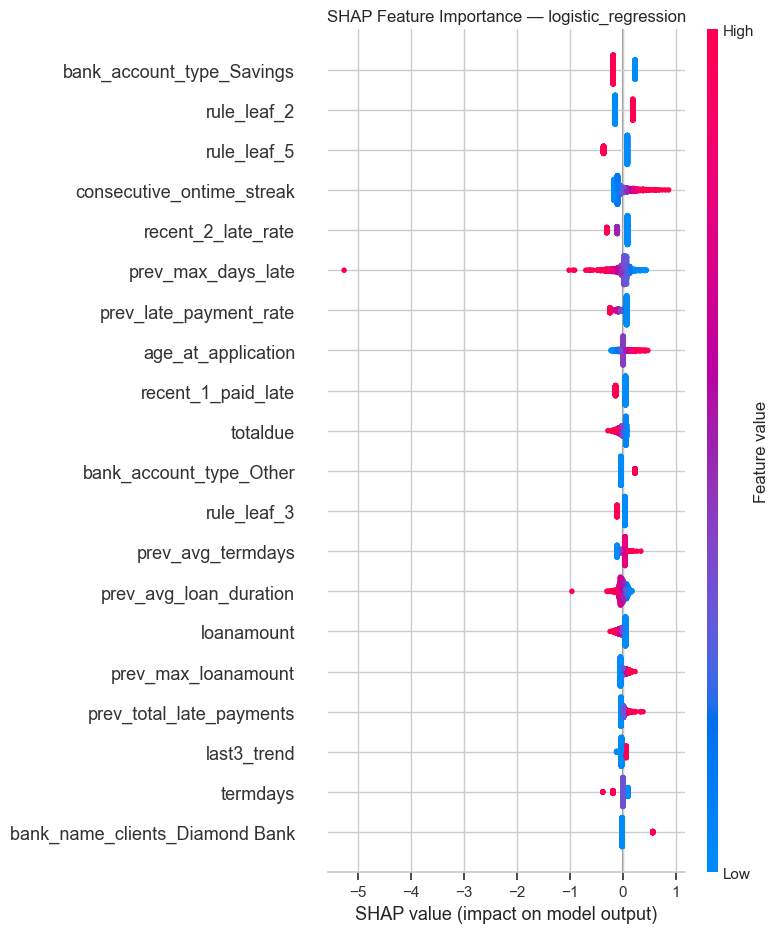

In [18]:
plot_shap_summary(tuned_models["logistic_regression"], X_val, model_name="logistic_regression")

## 12. Summary of Results Across All Iterations

| Version | Val ROC-AUC | Recall Bad | F1 Bad | LB Score |
|---|---|---|---|---|
| Baseline | 0.6885 | 0.6545 | 0.4325 | 0.4007 |
| Iteration 2 (recency features) | 0.6929 | 0.6073 | 0.4386 | 0.3448 |
| Iteration 3 (pruned features) | 0.6861 | 0.6545 | 0.4371 | 0.3703 |
| Iteration 4 (stacking) | 0.6865 | 0.5707 | 0.4360 | 0.3448 |
| Iteration 5 (time-based val) | 0.7214 | 0.6122 | 0.4727 | 0.2503 |
| Iteration 6 (time CV tuning) | 0.7163 | 0.5510 | 0.4909 | 0.2683 |
| Iteration 7 (stack tuned) | 0.7244 | 0.5663 | 0.4764 | 0.2731 |

## 13. Generate Zindi Submission

**NOTE:** Always pass `train_columns` when processing test data.

In [25]:

best_stack = stack_results["LR+RF (C=1.0)"]["model"]
submit_threshold = 0.35

test_df = load_and_merge(split="test")
X_test, _ = engineer_model_features(test_df, is_train=False, train_columns=X_train.columns.tolist())
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

test_proba = predict_proba(best_stack, X_test_imp)
test_pred  = (test_proba >= submit_threshold).astype(int)

print(f"Threshold used: {submit_threshold}")
print(f"Predictions: {pd.Series(test_pred).value_counts().to_dict()}")

submission = pd.DataFrame({
    "customerid": test_df["customerid"].values,
    "Good_Bad_flag": test_pred
})
submission_path = f"../outputs/submissions/submission_it11_thresh{submit_threshold}.csv"
submission.to_csv(submission_path, index=False)
print(f"Saved to {submission_path}")
submission.head()

Threshold used: 0.35
Predictions: {1: 1217, 0: 233}
Saved to ../outputs/submissions/submission_it11_thresh0.35.csv


,customerid,Good_Bad_flag
0,8a858899538ddb8e015390510b321f08,1
1,8a858959537a097401537a4e316e25f7,1
2,8a8589c253ace09b0153af6ba58f1f31,1
3,8a858e095aae82b7015aae86ca1e030b,1
4,8a858e225a28c713015a30db5c48383d,1
